 **Telco Customer Churn - Data Exploration**



 Goal: Explore and understand the raw dataset before cleaning,

 preprocessing, or model training.

**EDA Checklist**

- [x] Load data
- [x] Understand structure
- [x] Check data quality
- [x] Basic statistics
- [x] Categorical exploration
- [x] Numerical exploration
- [x] Visualization
- [x] Feature vs Churn
- [x] Final findings

In [ ]:
from pathlib import Path

import pandas as pd

from telco_churn.data import load_raw_dataset

 **1. Check the Current Working Directory**

In [5]:
Path.cwd()

WindowsPath('c:/Users/workA/codework/telco-customer-churn-pipeline/notebooks')

 **2. Define the Dataset Path**

In [6]:
from pathlib import Path

data_path = Path("../data/raw/Telco-Customer-Churn.csv")

if not data_path.exists():
    fallback_path = Path("data/raw/Telco-Customer-Churn.csv")

    if fallback_path.exists():
        data_path = fallback_path
    else:
        raise FileNotFoundError(
            "Dataset not found.\n\n"
            "Please download the IBM Telco Customer Churn dataset from:\n"
            "https://github.com/IBM/telco-customer-churn-on-icp4d/"
            "blob/master/data/Telco-Customer-Churn.csv\n\n"
            "Then save it as:\n"
            "data/raw/Telco-Customer-Churn.csv"
        )

print(f"Dataset found: {data_path.resolve()}")

Dataset found: C:\Users\workA\codework\telco-customer-churn-pipeline\data\raw\Telco-Customer-Churn.csv


 **3. Load the Raw Dataset**
 
 Read the CSV file into a Pandas DataFrame without cleaning it first.

In [7]:
data = load_raw_dataset(data_path)

 **4. Check the Dataset Size**
 
 Check how many customer records and variables are in the dataset.

In [ ]:
rows, columns = data.shape

print(f"Rows: {rows}")
print(f"Columns: {columns}")

 **5. Preview the Dataset**

 View the first few rows to understand the structure and example values.

In [10]:
data.head()



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


 **6. Inspect Column Types**

Check column names, data types, and non-null values.

In [11]:
data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


 **7. Check Unique Values**
 
Compare each column's data type and number of unique values.

This helps us quickly identify possible:
- identifiers
- categorical variables
- numerical variables

The number of unique values alone does not determine the variable type.

The meaning of the column must also be considered.

In [10]:
column_summary = (
    data.dtypes
    .to_frame(name="dtype")
    .assign(unique_values=data.nunique(dropna=False))
    .sort_values("unique_values")
)

column_summary



,dtype,unique_values
gender,object,2
SeniorCitizen,int64,2
Partner,object,2
Dependents,object,2
PhoneService,object,2
PaperlessBilling,object,2
Churn,object,2
MultipleLines,object,3
TechSupport,object,3
StreamingTV,object,3


dtype tells us how Pandas stores the data; unique values help us understand what the data repr`esents.`

 **8. Inspect Important Columns**

 Compare the stored data types of several important columns.

In [11]:
data[
    [
        "customerID",
        "SeniorCitizen",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Churn",
    ]
].dtypes



customerID         object
SeniorCitizen       int64
tenure              int64
MonthlyCharges    float64
TotalCharges       object
Churn              object
dtype: object

 **9. Interpret Important Columns**



 Findings:



 **customerID**

 - Unique identifier

 - Not suitable as a model feature



 **SeniorCitizen**

 - Stored as 0 and 1

 - Semantically categorical



 **TotalCharges**

 - Stored as object

 - Contains blank strings



 **Churn**

 - Target variable

 - Two classes: Yes and No

**10. Check missing / blank values**

In [12]:
data.isna().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**11. Check duplicates**

In [14]:
data.duplicated().sum()


np.int64(0)

**12. Basic statistics**

In [15]:
data.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**13. Check target distribution**

Check the class distribution of the target variable `Churn`.

In [20]:
# data["Churn"].value_counts()
data["Churn"].value_counts(normalize=True)
# data["Churn"].value_counts(normalize=True).to_frame(name="proportion").sort_index()

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Findings:
- About 73.5% of customers did not churn.
- About 26.5% of customers churned.
- The target is moderately imbalanced.

**14. Explore Categorical Variables**

Understand the categories and distribution of important categorical variables.

first inspect each variable by itself before comparing it with `Churn`.

In [21]:
data["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Questions:

1. How many contract types are there? 3
2. Which contract type has the most customers? month to month
3. Which contract type has the fewest customers?  one year

In [22]:
data["Contract"].value_counts(normalize=True)

Contract
Month-to-month    0.550192
Two year          0.240664
One year          0.209144
Name: proportion, dtype: float64

In [24]:
data["InternetService"].value_counts(normalize=True)

InternetService
Fiber optic    0.439585
DSL            0.343746
No             0.216669
Name: proportion, dtype: float64

In [25]:
data["PaymentMethod"].value_counts(normalize=True)

PaymentMethod
Electronic check             0.335794
Mailed check                 0.228880
Bank transfer (automatic)    0.219225
Credit card (automatic)      0.216101
Name: proportion, dtype: float64

In [26]:
data["TechSupport"].value_counts()

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

Questions:

1. What categories exist in `TechSupport`? No\Yes\No internet service
2. Is this simply a Yes/No variable? No
3. Why might there be a category such as `No internet service`?
   - Customers without internet service cannot have TechSupport.
   - This category means TechSupport is not applicable to them.

In [27]:
categorical_columns = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport",
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(data[column].value_counts())


--- Contract ---
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- PaymentMethod ---
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

--- TechSupport ---
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64


**15. Explore More Categorical Variables**

Understand the distribution of important categorical variables before comparing them with `Churn`.

In [8]:
data["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [9]:
data["InternetService"].value_counts(normalize=True)

InternetService
Fiber optic    0.439585
DSL            0.343746
No             0.216669
Name: proportion, dtype: float64

Questions:

1. How many Internet service categories are there? 3
2. Which category has the most customers? Fiber
3. Which category has the fewest customers? No
4. What proportion of customers belongs to each category? 

In [10]:
data["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

Questions:

1. How many payment methods are there? 4
2. Which payment method is the most common? Electronic check
3. Which payment method is the least common? 
4. What proportion of customers uses each payment method?

**16. Review Selected Categorical Variables**

Review the distributions of several important categorical variables in one place.

In [11]:
categorical_columns = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "PaperlessBilling",
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(data[column].value_counts())


--- Contract ---
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- PaymentMethod ---
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

--- TechSupport ---
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

--- PaperlessBilling ---
PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64


**17. Explore Numerical Variables**

Examine the range and distribution of important numerical variables.

In [12]:
data["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [13]:
data["MonthlyCharges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

Questions:

1. What is the minimum monthly charge? 18.25
2. What is the maximum monthly charge? 118.75
3. What is the average monthly charge? 64.76
4. What is the median monthly charge?  70.35
5. How large is the range between the minimum and maximum?
   - 118.75 - 18.25 = 100.50

In [14]:
data[
    [
        "tenure",
        "MonthlyCharges",
    ]
].describe()

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


In [15]:
(data["TotalCharges"].str.strip() == "").sum()

np.int64(11)

In [ ]:
# import pandas as pd

total_charges_numeric = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce", #turn the values that cannot be converted to numeric into NaN
)

total_charges_numeric.describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

In [19]:
total_charges_numeric.isna().sum()

np.int64(11)

**18. Explore TotalCharges**

`TotalCharges` is expected to be numerical, but Pandas currently stores it as `object`.

Check whether blank values are causing this issue.

In [20]:
(data["TotalCharges"].str.strip() == "").sum()

np.int64(11)

Questions:

1. How many blank values are in `TotalCharges`? 
2. Why might these blank values prevent Pandas from treating the column as numeric?

In [23]:
total_charges_numeric = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce",
)

total_charges_numeric.describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

**19. Visualize Numerical Distributions**

Use histograms to understand how numerical values are distributed.

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

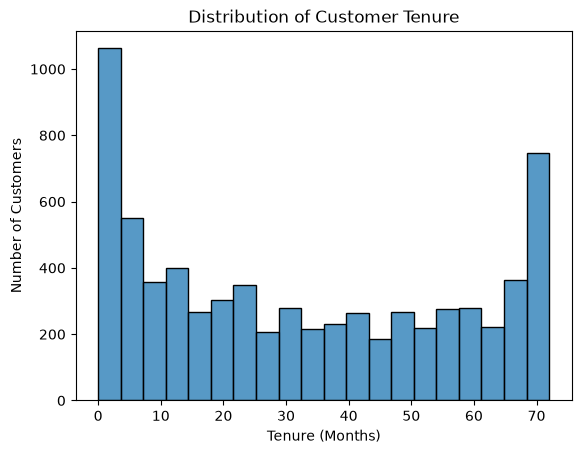

In [26]:
sns.histplot(data=data, x="tenure", bins=20)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

Questions:

1. Are customers concentrated in any particular tenure range?
   - Yes. Many customers are concentrated at very low tenure, and another large group is near 70–72 months.
2. Are there many new customers with low tenure? yes
3. Are there many long-term customers near 72 months? yes
4. Does the distribution look balanced or uneven? uneven

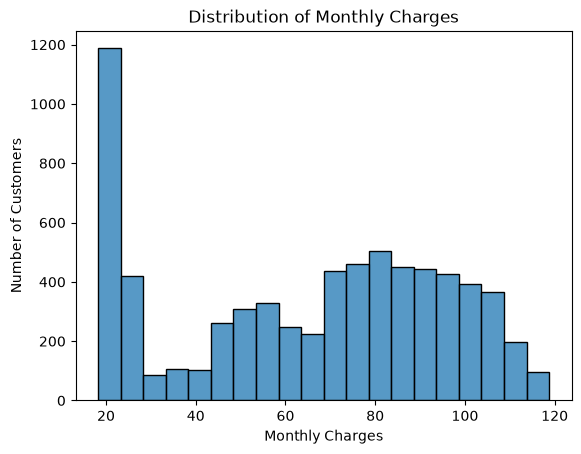

In [27]:
sns.histplot(data=data, x="MonthlyCharges", bins=20)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

In [28]:
total_charges_numeric

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

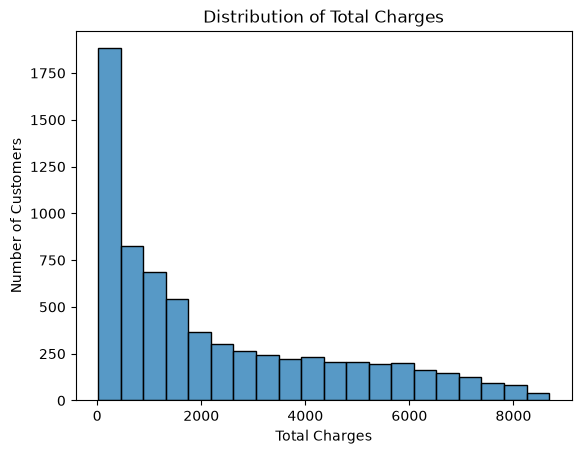

In [29]:
sns.histplot(x=total_charges_numeric, bins=20)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")
plt.show()

**20. Visualize Monthly Charges**

Use a histogram to understand how customer monthly charges are distributed.

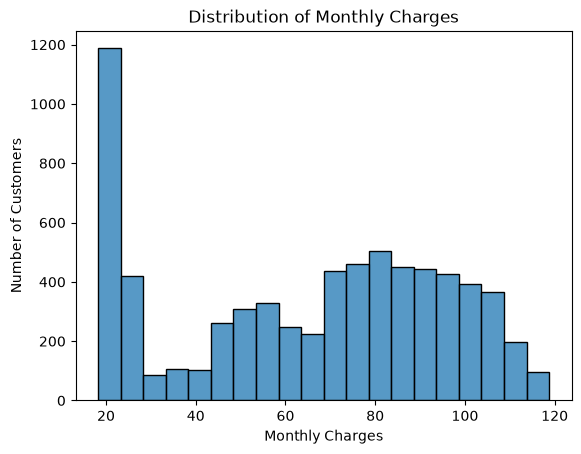

In [30]:
sns.histplot(data=data, x="MonthlyCharges", bins=20)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

Questions:

1. Where are most customers' monthly charges concentrated? 
   - There is a very large group around 20, and another broad concentration around 70-100.
2. Are there many customers with very low monthly charges? yes
3. Does the distribution have one clear peak or multiple peaks? multiple peaks
4. Does the distribution look balanced or uneven? uneven
5. Does the plot help explain why the mean (64.76) is lower than the median (70.35)?
   - Yes. The large number of customers with very low monthly charges pulls the mean downward.

**21. Visualize Total Charges**

Use a histogram to understand how total customer charges are distributed.

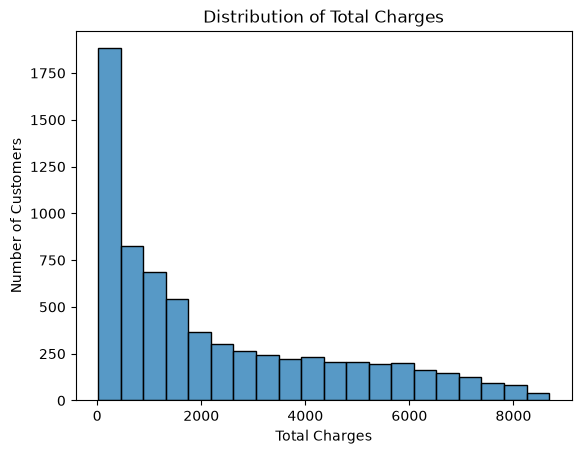

In [33]:
total_charges_numeric = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce",
)

sns.histplot(x=total_charges_numeric, bins=20)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")
plt.show()

Questions:

1. Where are most `TotalCharges` values concentrated?
   - At the lower end, especially below around 1,000.
2. Are there many customers with low total charges? yes
3. Are there fewer customers with very high total charges? yes
4. Does the distribution look symmetric or skewed? skewed
5. If it is skewed, which direction does it appear to be skewed? right skewed

---
Long tail on the right
→ right-skewed

Long tail on the left
→ left-skewed

**22. Visualize Numerical Variables with Box Plots**

Use box plots to examine the spread and possible outliers of numerical variables.

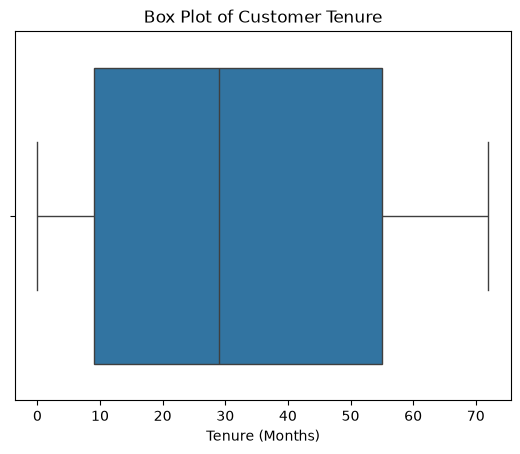

In [34]:
sns.boxplot(x=data["tenure"])

plt.title("Box Plot of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.show()

Questions:

1. What is the approximate median tenure?
   - About 29-30 months.
2. Where is the middle 50% of the data located?
   - Between about 9 and 55 months
3. Are there any obvious outliers? no
4. Does the distribution look roughly balanced around the median?
   - Not perfectly. The upper half is slightly more spread out than the lower half.

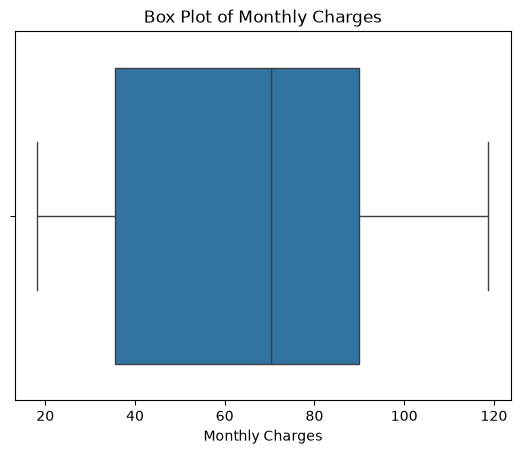

In [35]:
sns.boxplot(x=data["MonthlyCharges"])

plt.title("Box Plot of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.show()

Questions:

1. What is the approximate median monthly charge? about 70
2. Where is the middle 50% of the data located? between 35 - 89
3. Are there any obvious outliers? no
4. Is the median located near the center of the box?
   - No. The median is closer to the upper quartile (Q3).

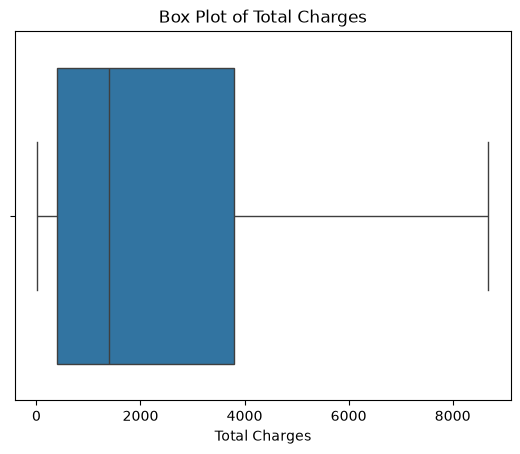

In [36]:
sns.boxplot(x=total_charges_numeric)

plt.title("Box Plot of Total Charges")
plt.xlabel("Total Charges")
plt.show()

**23. Box Plot of Total Charges**

Use a box plot to examine the spread, skewness, and possible outliers of `TotalCharges`.

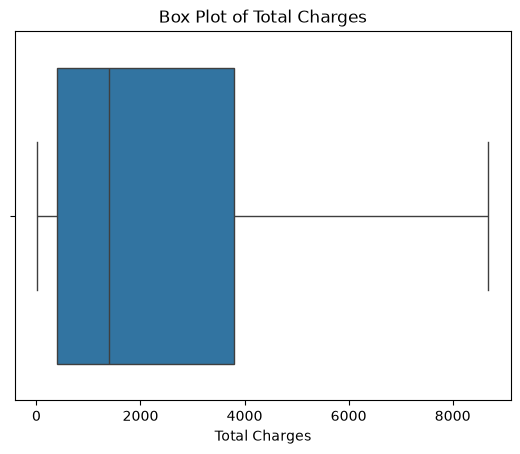

In [37]:
sns.boxplot(x=total_charges_numeric)

plt.title("Box Plot of Total Charges")
plt.xlabel("Total Charges")
plt.show()

Questions:

1. What is the approximate median TotalCharges?
   - About 1,400–1,500.
2. Where is the middle 50% of the data located?
   - Approximately between 400 and 3,800.
3. Is one whisker longer than the other? 
   - Yes. The right whisker is much longer.
4. Does the box plot support the right-skewed pattern seen in the histogram?
   - Tes
5. Are there any obvious outliers? no

**24. Contract vs Churn**

Compare churn rates across different contract types.

In [38]:
pd.crosstab(
    data["Contract"],
    data["Churn"],
)

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [39]:
pd.crosstab(
    data["Contract"],
    data["Churn"],
    normalize="index",
)

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


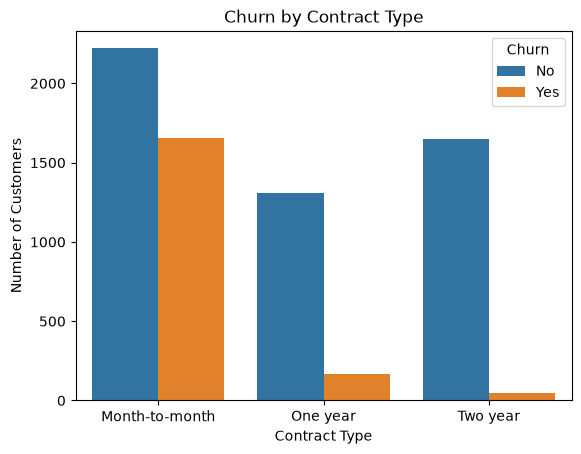

In [43]:
sns.countplot(
    data=data,
    x="Contract",
    hue="Churn",
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

**25. TechSupport vs Churn**

Compare churn rates across different `TechSupport` categories.

In [47]:
pd.crosstab(
    data["TechSupport"],
    data["Churn"],
)

Churn,No,Yes
TechSupport,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


In [45]:
pd.crosstab(
    data["TechSupport"],
    data["Churn"],
    normalize="index",
)

Churn,No,Yes
TechSupport,,
No,0.583645,0.416355
No internet service,0.925950,0.074050
Yes,0.848337,0.151663


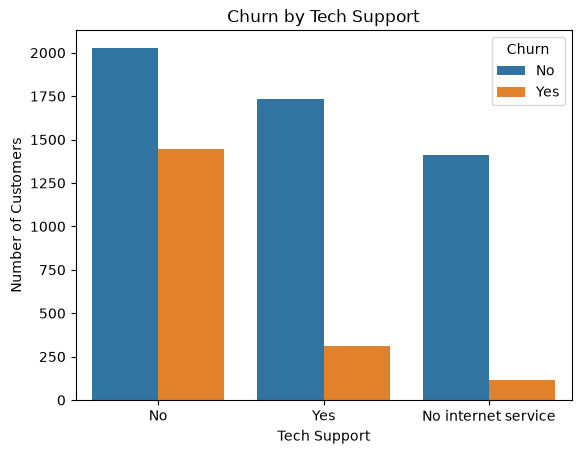

In [48]:
sns.countplot(
    data=data,
    x="TechSupport",
    hue="Churn"
)

plt.title("Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")
plt.show()

**26. Tenure vs Churn**

Compare customer tenure between churned and non-churned customers.

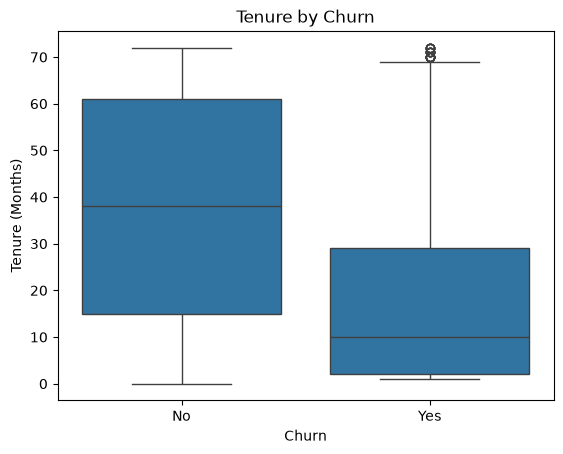

In [49]:
sns.boxplot(
    data=data,
    x="Churn",
    y="tenure",
)

plt.title("Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

Questions:

1. Which group has the lower median tenure? churn = yes
2. Which group contains more customers with short tenure? churn = yes
3. Which group has a wider tenure range? churn = no
4. Does tenure appear to be associated with churn? 
   - Yes. Customers who churned generally have shorter tenure.

#### Box Plot

A box plot summarizes the distribution of numerical data.

- Box = middle 50% of the data (Q1 to Q3)
- Line inside the box = median
- Whiskers = typical data range
- Points outside = possible outliers

Useful for comparing the distribution of a numerical variable between groups.

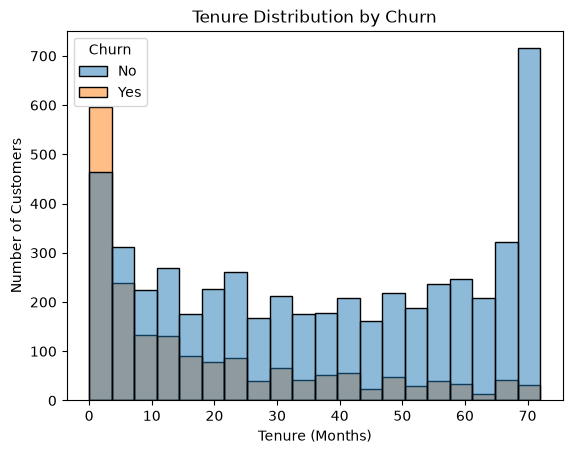

In [50]:
sns.histplot(
    data=data,
    x="tenure",
    hue="Churn",
    bins=20,
    multiple="layer",
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

Questions:

1. Are churned customers concentrated at lower tenure values? yes
2. Are non-churned customers more common at higher tenure values? yes
3. Does the histogram support the pattern seen in the box plot? yes

**27. Monthly Charges vs Churn**

Compare monthly charges between churned and non-churned customers.

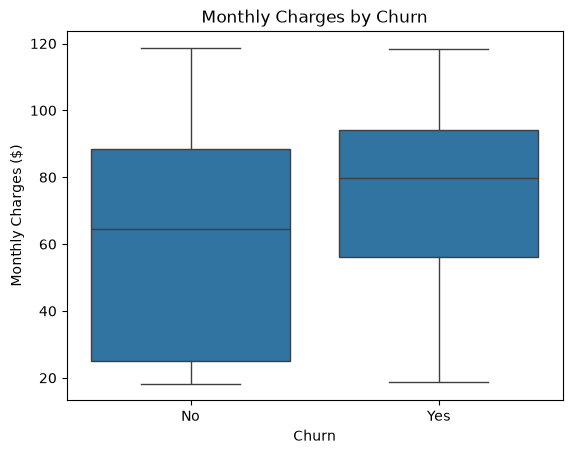

In [51]:
sns.boxplot(
    data=data,
    x="Churn",
    y="MonthlyCharges",
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges ($)")
plt.show()

Questions:

1. Which group has the higher median monthly charge? churn = yes
2. Which group has the wider middle 50% range (IQR)? churn = no
3. Do churned customers generally have higher monthly charges? yes
4. Does MonthlyCharges appear to be associated with churn? yes

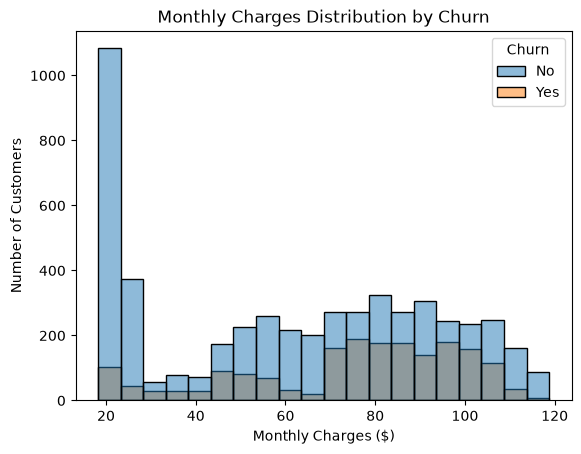

In [52]:
sns.histplot(
    data=data,
    x="MonthlyCharges",
    hue="Churn",
    bins=20,
    multiple="layer",
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Number of Customers")
plt.show()

Questions:

1. At which monthly charge ranges are churned customers more concentrated?
   - Mostly in the medium-to-high range, roughly around 70–105.
2. Are low-charge customers less common among churned customers?
   - Yes.
3. Are churned customers more concentrated in the medium-to-high charge range?
   - Yes.
4. Does the histogram support the pattern seen in the box plot?
   - Yes.

**28. Final EDA Findings**

Summarize the main patterns observed during data exploration.

- The dataset contains 7,043 customers and 21 columns. Churn is the target, with 26.5% of customers churned and 73.5% retained.
- Month-to-month contracts are the most common (55% of customers) and have the highest churn rate (42.7%), compared with 11.3% for one-year contracts and 2.8% for two-year contracts.
- Churned customers generally have shorter tenure and higher monthly charges than customers who stay.
- Customers without TechSupport have a higher churn rate (41.6%) than customers with TechSupport (15.2%). This is an association, not evidence that support access alone causes retention.
- Tenure varies widely (median 29 months); monthly charges also span a wide range (median $70.35).
- TotalCharges is stored as text and contains blank strings, so it needs cleaning and numeric conversion before analysis or modeling.